In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np
import io
import json

In [3]:
path_to_img = "./cifake/test/FAKE/100 (10).jpg"
img = Image.open(path_to_img)

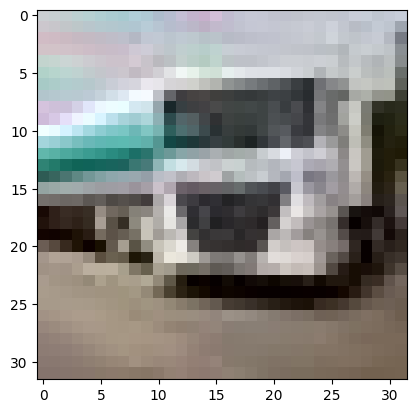

In [4]:
plt.imshow(img)

In [5]:
transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )
img_transformed = transform(img)

In [6]:
image = np.array(img_transformed).astype(np.float32)
image = np.expand_dims(image, axis=0)

In [7]:
import sagemaker

pandas failed to import. Analytics features will be impaired or broken.


In [8]:
ENDPOINT = 'detectingSyntheticImages'

In [10]:
# Instantiate a Predictor
predictor = sagemaker.predictor.Predictor(ENDPOINT, sagemaker_session=sagemaker.Session())

In [18]:
image_b = image.tobytes()

In [22]:

# Make a prediction:
inferences = predictor.predict(image_b, initial_args={"ContentType": "bytes"})

ModelError: An error occurred (ModelError) when calling the InvokeEndpoint operation: Received server error (500) from primary and could not load the entire response body. See https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#logEventViewer:group=/aws/sagemaker/Endpoints/detectingSyntheticImages in account 257909240325 for more information.

In [ ]:
predictions = predictor.predict(image, initial_args={'ContentType': 'application/x-npy'})